# 🏥 Disease Prediction from Medical Data
**CodeAlpha Machine Learning Internship — Task 4**

---

### Objective
Predict the possibility of diseases (Heart Disease, Diabetes, Breast Cancer) based on patient medical data using classification algorithms.

### Datasets Used
- Heart Disease Dataset (UCI)
- Diabetes Dataset (Pima Indians — Kaggle)
- Breast Cancer Dataset (sklearn built-in)

### Workflow
1. Load & explore datasets
2. Data preprocessing
3. EDA & visualizations
4. Train multiple models
5. Compare & evaluate
6. Predict on new patient data
7. Save best model

## Step 1: Install & Import Libraries

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle

print('All libraries imported successfully!')

All libraries imported successfully!


---
# 🫀 Part 1: Heart Disease Prediction

## Step 2: Load Heart Disease Dataset

In [3]:
# Load from UCI via URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

heart_df = pd.read_csv(url, header=None, names=columns, na_values='?')

# Binary target: 0 = no disease, 1 = disease
heart_df['target'] = (heart_df['target'] > 0).astype(int)

print('Heart Disease Dataset:')
print(f'Shape: {heart_df.shape}')
print(f'Missing values:\n{heart_df.isnull().sum()}')
heart_df.head()

Heart Disease Dataset:
Shape: (303, 14)
Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Basic statistics
print('Target distribution:')
print(heart_df['target'].value_counts())
print('\n0 = No Heart Disease | 1 = Heart Disease')
heart_df.describe()

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

0 = No Heart Disease | 1 = Heart Disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Step 3: EDA — Heart Disease

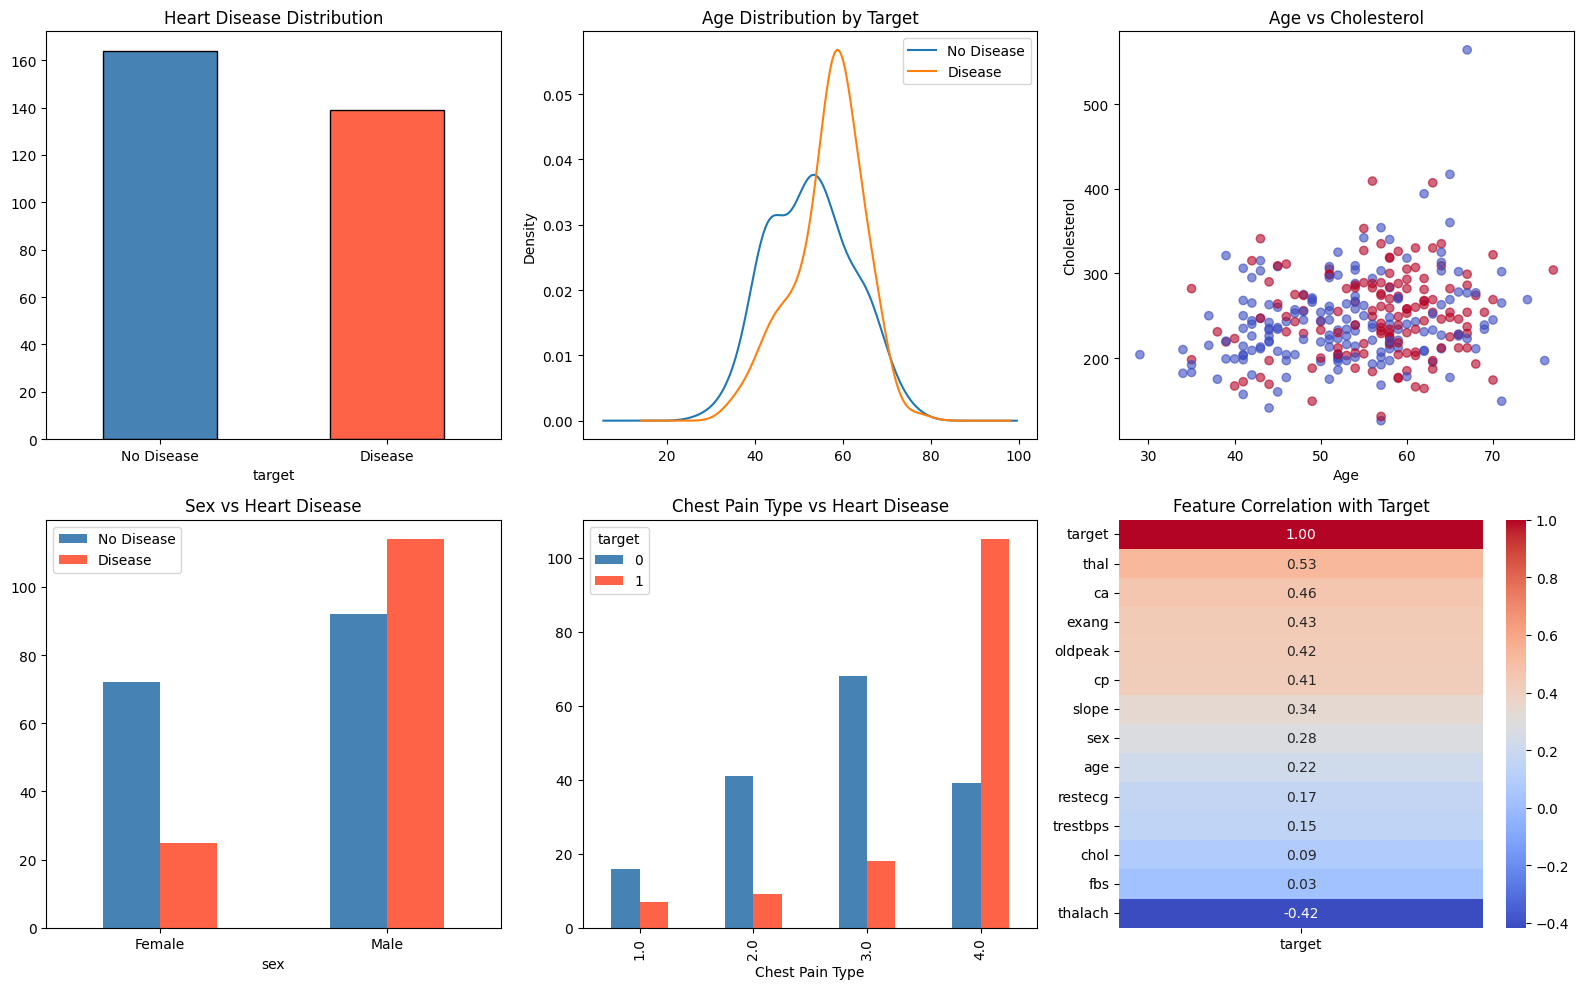

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Target distribution
heart_df['target'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title('Heart Disease Distribution')
axes[0,0].set_xticklabels(['No Disease', 'Disease'], rotation=0)

# Age distribution by target
heart_df.groupby('target')['age'].plot(kind='kde', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Target')
axes[0,1].legend(['No Disease', 'Disease'])

# Cholesterol vs age
axes[0,2].scatter(heart_df['age'], heart_df['chol'], c=heart_df['target'], cmap='coolwarm', alpha=0.6)
axes[0,2].set_title('Age vs Cholesterol')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Cholesterol')

# Sex distribution
pd.crosstab(heart_df['sex'], heart_df['target']).plot(kind='bar', ax=axes[1,0], color=['steelblue','tomato'])
axes[1,0].set_title('Sex vs Heart Disease')
axes[1,0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1,0].legend(['No Disease', 'Disease'])

# Chest pain type
pd.crosstab(heart_df['cp'], heart_df['target']).plot(kind='bar', ax=axes[1,1], color=['steelblue','tomato'])
axes[1,1].set_title('Chest Pain Type vs Heart Disease')
axes[1,1].set_xlabel('Chest Pain Type')

# Correlation heatmap
corr = heart_df.corr()
sns.heatmap(corr[['target']].sort_values('target', ascending=False),
            annot=True, cmap='coolwarm', ax=axes[1,2], fmt='.2f')
axes[1,2].set_title('Feature Correlation with Target')

plt.tight_layout()
plt.show()

## Step 4: Preprocessing & Model Training — Heart Disease

In [6]:
# Handle missing values
heart_df.dropna(inplace=True)

X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# Scale features
scaler_heart = StandardScaler()
X_heart_scaled = scaler_heart.fit_transform(X_heart)

# Train-test split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart_scaled, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

# Train multiple models
heart_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

heart_results = {}
print('Heart Disease Model Results:')
print('-' * 60)

for name, clf in heart_models.items():
    clf.fit(X_train_h, y_train_h)
    y_pred = clf.predict(X_test_h)
    y_prob = clf.predict_proba(X_test_h)[:, 1]
    acc = accuracy_score(y_test_h, y_pred)
    f1  = f1_score(y_test_h, y_pred)
    auc = roc_auc_score(y_test_h, y_prob)
    cv  = cross_val_score(clf, X_heart_scaled, y_heart, cv=5, scoring='accuracy').mean()
    heart_results[name] = {'Accuracy': acc, 'F1 Score': f1, 'ROC-AUC': auc, 'CV Score': cv}
    print(f'{name:<25} Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  CV={cv:.3f}')

heart_results_df = pd.DataFrame(heart_results).T
print('\nBest model:', heart_results_df['Accuracy'].idxmax())

Heart Disease Model Results:
------------------------------------------------------------
Logistic Regression       Acc=0.833  F1=0.815  AUC=0.950  CV=0.825
Random Forest             Acc=0.867  F1=0.852  AUC=0.937  CV=0.808
SVM                       Acc=0.850  F1=0.830  AUC=0.955  CV=0.821
XGBoost                   Acc=0.867  F1=0.852  AUC=0.892  CV=0.814

Best model: Random Forest


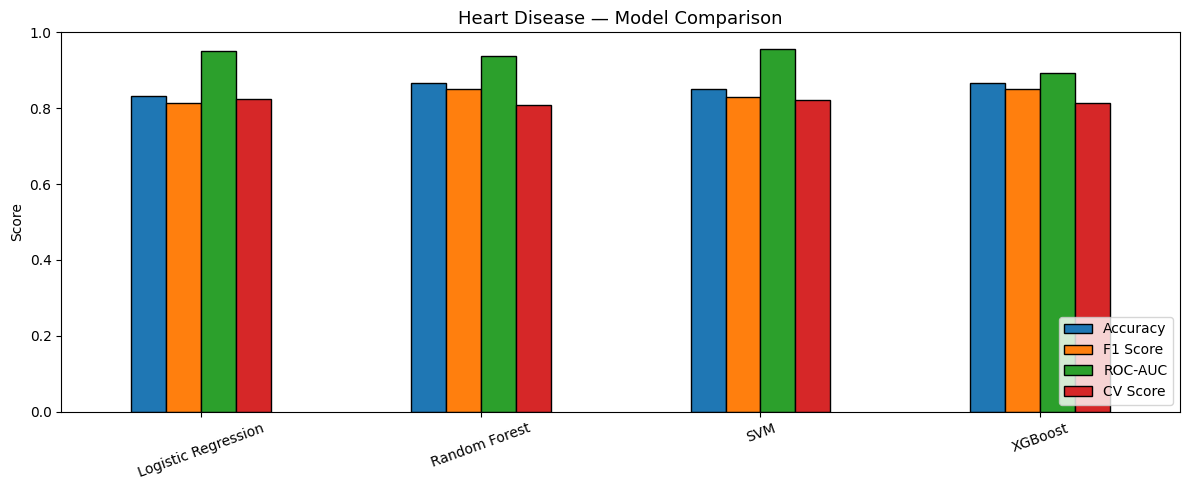

In [7]:
# Model comparison chart
heart_results_df.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Heart Disease — Model Comparison', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

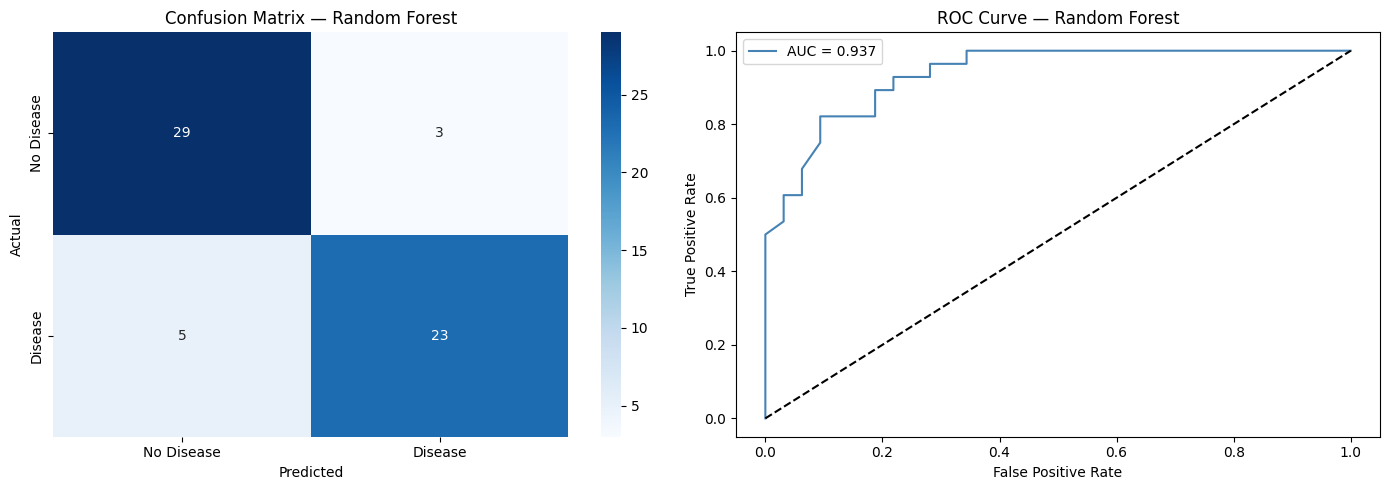


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.91      0.88        32
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



In [8]:
# Best model: Confusion matrix & ROC curve
best_heart_name = heart_results_df['Accuracy'].idxmax()
best_heart_model = heart_models[best_heart_name]
y_pred_best = best_heart_model.predict(X_test_h)
y_prob_best = best_heart_model.predict_proba(X_test_h)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test_h, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
axes[0].set_title(f'Confusion Matrix — {best_heart_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test_h, y_prob_best)
auc = roc_auc_score(y_test_h, y_prob_best)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--')
axes[1].set_title(f'ROC Curve — {best_heart_name}')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test_h, y_pred_best, target_names=['No Disease', 'Disease']))

---
# 🩺 Part 2: Diabetes Prediction

## Step 5: Load Diabetes Dataset

In [9]:
# Pima Indians Diabetes Dataset
diabetes_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

dia_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
               'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

diabetes_df = pd.read_csv(diabetes_url, header=None, names=dia_columns)

print('Diabetes Dataset:')
print(f'Shape: {diabetes_df.shape}')
print(f'\nTarget distribution:')
print(diabetes_df['Outcome'].value_counts())
print('\n0 = No Diabetes | 1 = Diabetes')
diabetes_df.head()

Diabetes Dataset:
Shape: (768, 9)

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

0 = No Diabetes | 1 = Diabetes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


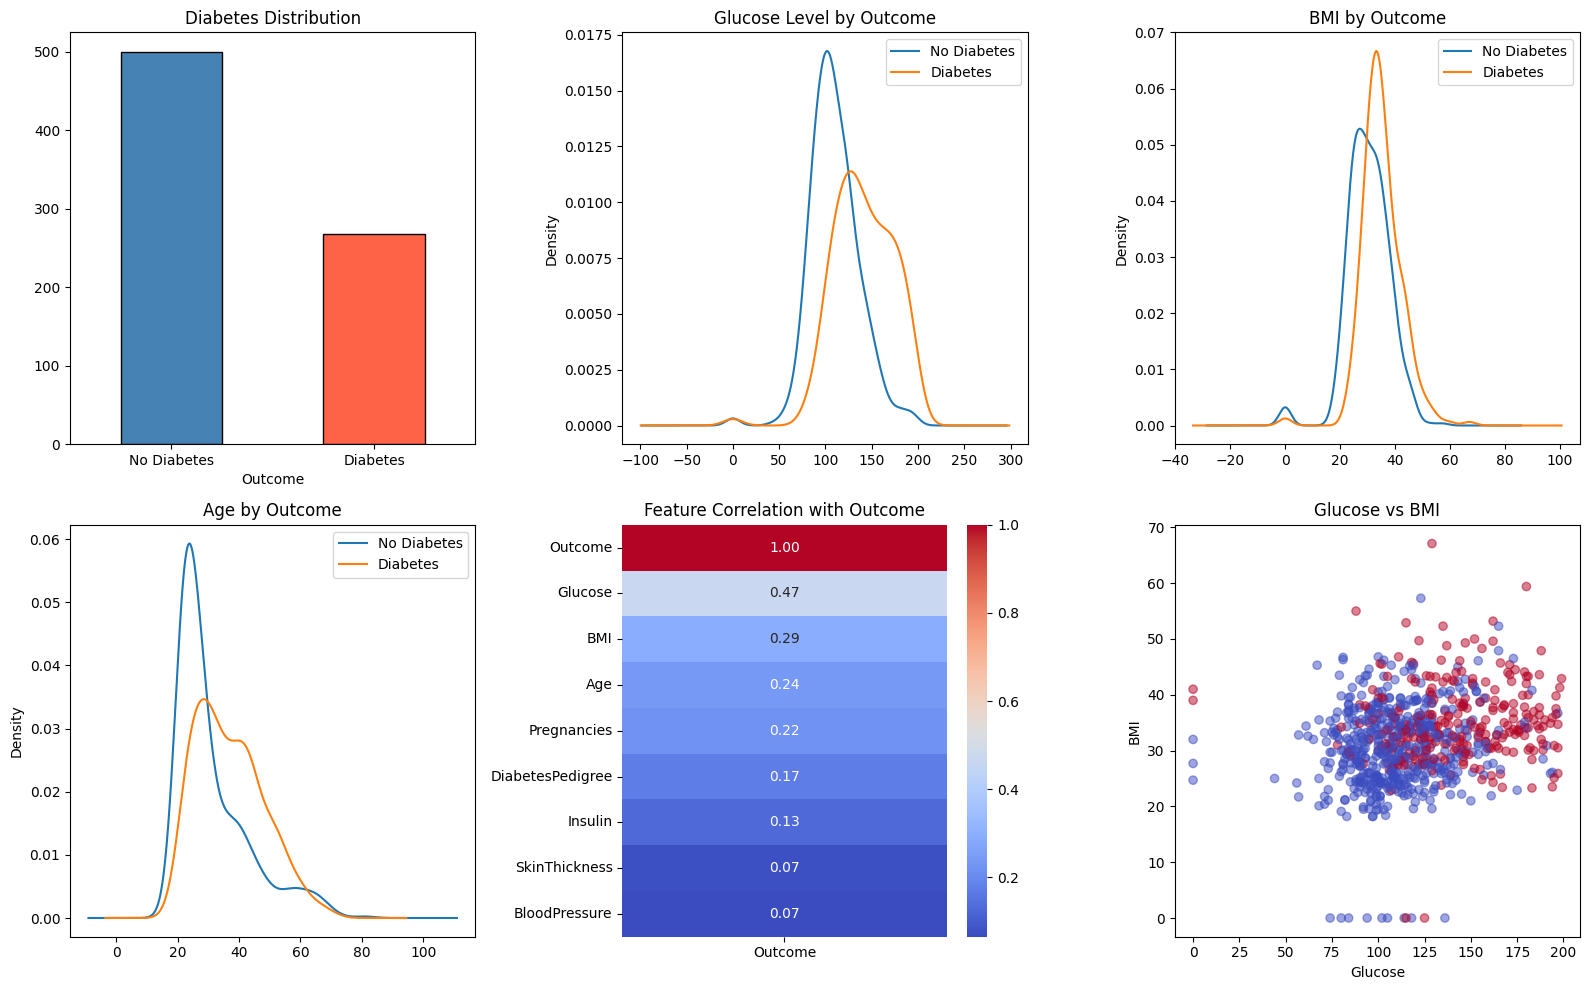

In [10]:
# EDA — Diabetes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Outcome distribution
diabetes_df['Outcome'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title('Diabetes Distribution')
axes[0,0].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# Glucose by outcome
diabetes_df.groupby('Outcome')['Glucose'].plot(kind='kde', ax=axes[0,1])
axes[0,1].set_title('Glucose Level by Outcome')
axes[0,1].legend(['No Diabetes', 'Diabetes'])

# BMI distribution
diabetes_df.groupby('Outcome')['BMI'].plot(kind='kde', ax=axes[0,2])
axes[0,2].set_title('BMI by Outcome')
axes[0,2].legend(['No Diabetes', 'Diabetes'])

# Age distribution
diabetes_df.groupby('Outcome')['Age'].plot(kind='kde', ax=axes[1,0])
axes[1,0].set_title('Age by Outcome')
axes[1,0].legend(['No Diabetes', 'Diabetes'])

# Correlation heatmap
corr = diabetes_df.corr()
sns.heatmap(corr[['Outcome']].sort_values('Outcome', ascending=False),
            annot=True, cmap='coolwarm', ax=axes[1,1], fmt='.2f')
axes[1,1].set_title('Feature Correlation with Outcome')

# Pairplot-style scatter
axes[1,2].scatter(diabetes_df['Glucose'], diabetes_df['BMI'],
                  c=diabetes_df['Outcome'], cmap='coolwarm', alpha=0.5)
axes[1,2].set_title('Glucose vs BMI')
axes[1,2].set_xlabel('Glucose')
axes[1,2].set_ylabel('BMI')

plt.tight_layout()
plt.show()

In [11]:
# Preprocessing
# Replace 0s in medical columns with median (biologically impossible to be 0)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    diabetes_df[col] = diabetes_df[col].replace(0, diabetes_df[col].median())

X_dia = diabetes_df.drop('Outcome', axis=1)
y_dia = diabetes_df['Outcome']

scaler_dia = StandardScaler()
X_dia_scaled = scaler_dia.fit_transform(X_dia)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dia_scaled, y_dia, test_size=0.2, random_state=42, stratify=y_dia
)

# Train models
dia_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

dia_results = {}
print('Diabetes Model Results:')
print('-' * 60)

for name, clf in dia_models.items():
    clf.fit(X_train_d, y_train_d)
    y_pred = clf.predict(X_test_d)
    y_prob = clf.predict_proba(X_test_d)[:, 1]
    acc = accuracy_score(y_test_d, y_pred)
    f1  = f1_score(y_test_d, y_pred)
    auc = roc_auc_score(y_test_d, y_prob)
    cv  = cross_val_score(clf, X_dia_scaled, y_dia, cv=5, scoring='accuracy').mean()
    dia_results[name] = {'Accuracy': acc, 'F1 Score': f1, 'ROC-AUC': auc, 'CV Score': cv}
    print(f'{name:<25} Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  CV={cv:.3f}')

dia_results_df = pd.DataFrame(dia_results).T
print('\nBest model:', dia_results_df['Accuracy'].idxmax())

Diabetes Model Results:
------------------------------------------------------------
Logistic Regression       Acc=0.708  F1=0.545  AUC=0.815  CV=0.764
Random Forest             Acc=0.760  F1=0.634  AUC=0.821  CV=0.760
Gradient Boosting         Acc=0.760  F1=0.634  AUC=0.826  CV=0.770
XGBoost                   Acc=0.734  F1=0.610  AUC=0.810  CV=0.727

Best model: Random Forest


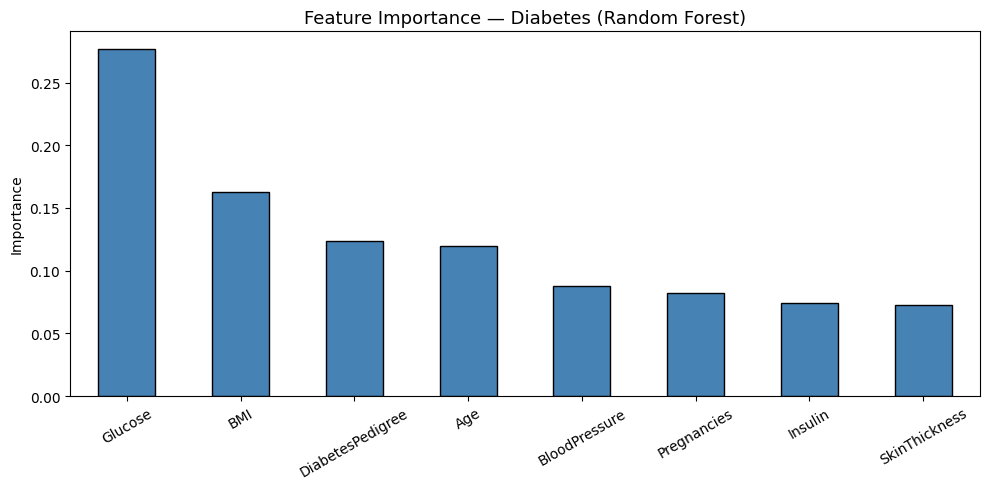

In [12]:
# Feature importance — Random Forest
rf_dia = dia_models['Random Forest']
feat_importance = pd.Series(rf_dia.feature_importances_, index=X_dia.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Diabetes (Random Forest)', fontsize=13)
plt.ylabel('Importance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
# 🎗️ Part 3: Breast Cancer Prediction

In [13]:
# Load sklearn built-in breast cancer dataset
bc = load_breast_cancer()
bc_df = pd.DataFrame(bc.data, columns=bc.feature_names)
bc_df['target'] = bc.target  # 0 = malignant, 1 = benign

print('Breast Cancer Dataset:')
print(f'Shape: {bc_df.shape}')
print(f'\nTarget distribution:')
print(bc_df['target'].value_counts())
print('0 = Malignant | 1 = Benign')

X_bc = bc_df.drop('target', axis=1)
y_bc = bc_df['target']

scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

bc_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

bc_results = {}
print('\nBreast Cancer Model Results:')
print('-' * 60)

for name, clf in bc_models.items():
    clf.fit(X_train_bc, y_train_bc)
    y_pred = clf.predict(X_test_bc)
    y_prob = clf.predict_proba(X_test_bc)[:, 1]
    acc = accuracy_score(y_test_bc, y_pred)
    f1  = f1_score(y_test_bc, y_pred)
    auc = roc_auc_score(y_test_bc, y_prob)
    cv  = cross_val_score(clf, X_bc_scaled, y_bc, cv=5, scoring='accuracy').mean()
    bc_results[name] = {'Accuracy': acc, 'F1 Score': f1, 'ROC-AUC': auc, 'CV Score': cv}
    print(f'{name:<25} Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}  CV={cv:.3f}')

bc_results_df = pd.DataFrame(bc_results).T
print('\nBest model:', bc_results_df['Accuracy'].idxmax())

Breast Cancer Dataset:
Shape: (569, 31)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64
0 = Malignant | 1 = Benign

Breast Cancer Model Results:
------------------------------------------------------------
Logistic Regression       Acc=0.982  F1=0.986  AUC=0.995  CV=0.981
Random Forest             Acc=0.956  F1=0.966  AUC=0.994  CV=0.956
SVM                       Acc=0.982  F1=0.986  AUC=0.995  CV=0.974
XGBoost                   Acc=0.956  F1=0.966  AUC=0.990  CV=0.974

Best model: Logistic Regression


---
## Step 6: Overall Model Comparison (All 3 Diseases)

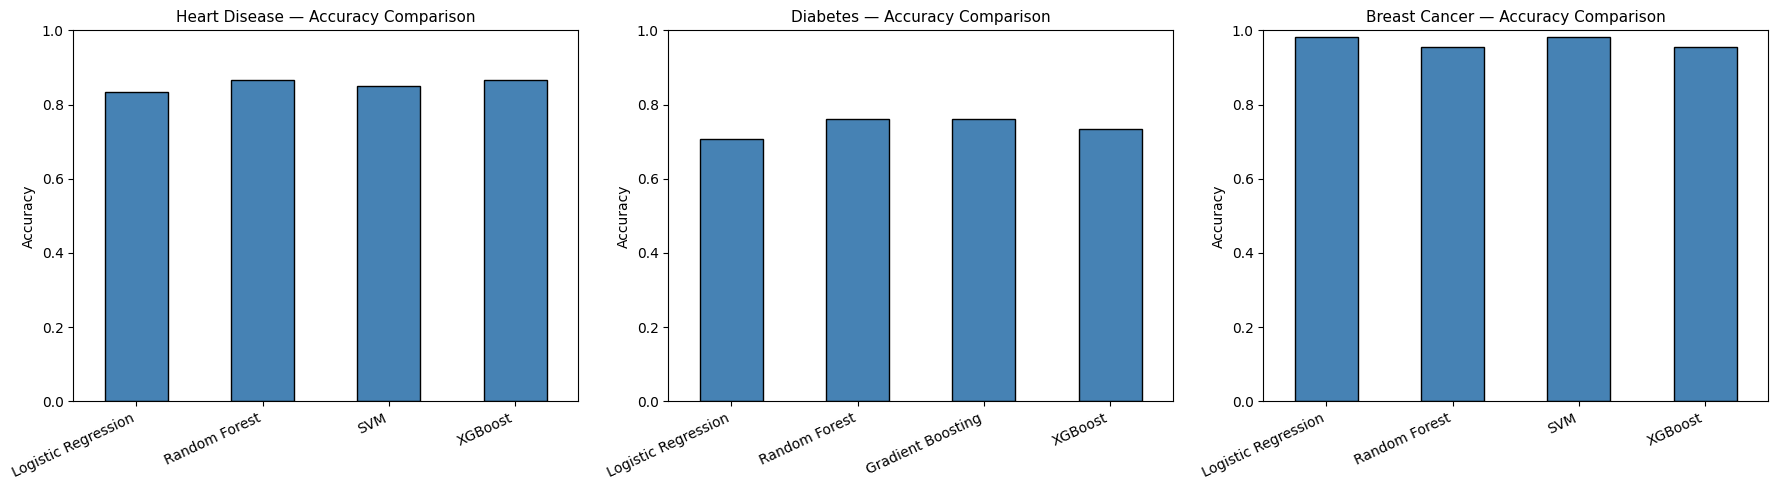

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, results_df, title in zip(
    axes,
    [heart_results_df, dia_results_df, bc_results_df],
    ['Heart Disease', 'Diabetes', 'Breast Cancer']
):
    results_df['Accuracy'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{title} — Accuracy Comparison', fontsize=11)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df.index, rotation=25, ha='right')

plt.tight_layout()
plt.show()

## Step 7: Predict on New Patient Data

In [15]:
def predict_heart_disease(patient_data: dict):
    """
    Predict heart disease for a new patient.
    patient_data keys: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
    """
    df_input = pd.DataFrame([patient_data])
    scaled = scaler_heart.transform(df_input)
    prob = best_heart_model.predict_proba(scaled)[0][1]
    result = 'HEART DISEASE DETECTED' if prob >= 0.5 else 'NO HEART DISEASE'
    print(f'Prediction  : {result}')
    print(f'Probability : {prob*100:.1f}% risk of heart disease')
    return result

# Example patient
new_patient_heart = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140, 'chol': 250,
    'fbs': 0, 'restecg': 1, 'thalach': 150, 'exang': 0,
    'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}

print('--- Heart Disease Prediction ---')
predict_heart_disease(new_patient_heart)

--- Heart Disease Prediction ---
Prediction  : NO HEART DISEASE
Probability : 13.0% risk of heart disease


'NO HEART DISEASE'

In [16]:
def predict_diabetes(patient_data: dict):
    """
    Predict diabetes for a new patient.
    patient_data keys: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigree, Age
    """
    best_dia_name = dia_results_df['Accuracy'].idxmax()
    best_dia_model = dia_models[best_dia_name]
    df_input = pd.DataFrame([patient_data])
    scaled = scaler_dia.transform(df_input)
    prob = best_dia_model.predict_proba(scaled)[0][1]
    result = 'DIABETIC' if prob >= 0.5 else 'NOT DIABETIC'
    print(f'Prediction  : {result}')
    print(f'Probability : {prob*100:.1f}% risk of diabetes')
    return result

# Example patient
new_patient_diabetes = {
    'Pregnancies': 2, 'Glucose': 138, 'BloodPressure': 80,
    'SkinThickness': 35, 'Insulin': 0, 'BMI': 33.6,
    'DiabetesPedigree': 0.627, 'Age': 45
}

print('--- Diabetes Prediction ---')
predict_diabetes(new_patient_diabetes)

--- Diabetes Prediction ---
Prediction  : DIABETIC
Probability : 68.0% risk of diabetes


'DIABETIC'

## Step 8: Save All Models

In [17]:
# Save models
models_to_save = {
    'heart_disease_model.pkl':   best_heart_model,
    'heart_scaler.pkl':          scaler_heart,
    'diabetes_model.pkl':        dia_models[dia_results_df['Accuracy'].idxmax()],
    'diabetes_scaler.pkl':       scaler_dia,
    'breast_cancer_model.pkl':   bc_models[bc_results_df['Accuracy'].idxmax()],
    'breast_cancer_scaler.pkl':  scaler_bc,
}

for filename, obj in models_to_save.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved: {filename}')

# Download all
from google.colab import files
for filename in models_to_save.keys():
    files.download(filename)

print('\nAll models saved and downloaded!')

Saved: heart_disease_model.pkl
Saved: heart_scaler.pkl
Saved: diabetes_model.pkl
Saved: diabetes_scaler.pkl
Saved: breast_cancer_model.pkl
Saved: breast_cancer_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All models saved and downloaded!


---
## ✅ Summary

| Disease | Dataset | Best Model | Key Metric |
|---------|---------|------------|------------|
| Heart Disease | UCI Cleveland | See results above | Accuracy, ROC-AUC |
| Diabetes | Pima Indians | See results above | Accuracy, F1 Score |
| Breast Cancer | sklearn built-in | See results above | Accuracy, ROC-AUC |

**Models used:** Logistic Regression, Random Forest, SVM, Gradient Boosting, XGBoost  
**Evaluation:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, Cross-Validation

**Author:** Geethanjali  
**Internship:** CodeAlpha Machine Learning Internship